# 实验 03：精密光学元件表面缺陷的监督学习多分类

**核心任务**：监督学习 (Supervised Learning) - 多分类 (Multi-class Classification)  
**数据集**：NEU Surface Defect Database (6 类工业缺陷)

## 1. 实验背景与目标
在工业 AOI (自动光学检测) 系统中，仅仅“训练一个模型”是不够的。我们需要验证模型的鲁棒性、泛化能力以及可解释性。
本实验将构建一个完整的深度学习流水线，解决**6分类**问题：`Crazing` (裂纹), `Inclusion` (夹杂), `Patches` (斑块), `Pitted` (麻点), `Rolled` (氧化皮), `Scratches` (划痕)。

**设计环节**：
1.  **特征工程**：引入 **CLAHE** 增强算法，对比其对低对比度缺陷的提升作用。
2.  **模型训练**：使用 ResNet 进行迁移学习，并监控训练过程中的 Loss/Acc 变化。
3.  **量化评估**：使用 Confusion Matrix 和 F1-Score 证明模型性能，而不仅仅看准确率。
4.  **可视化验证**：通过 Grad-CAM 证明模型确实关注到了缺陷纹理。


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import shutil
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import random

# 绘图设置
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei'] # 正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## 2. 数据准备与 EDA (探索性数据分析)
首先下载数据，并观察各类别的分布情况，确保数据基础是可靠的。


 数据集路径确认:
   Root : ..\data\NEU-DET
   Train: ..\data\NEU-DET\train\images
   Val  : ..\data\NEU-DET\validation\images


C:\Users\86177\AppData\Local\Temp\ipykernel_8500\1125081410.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette='viridis')


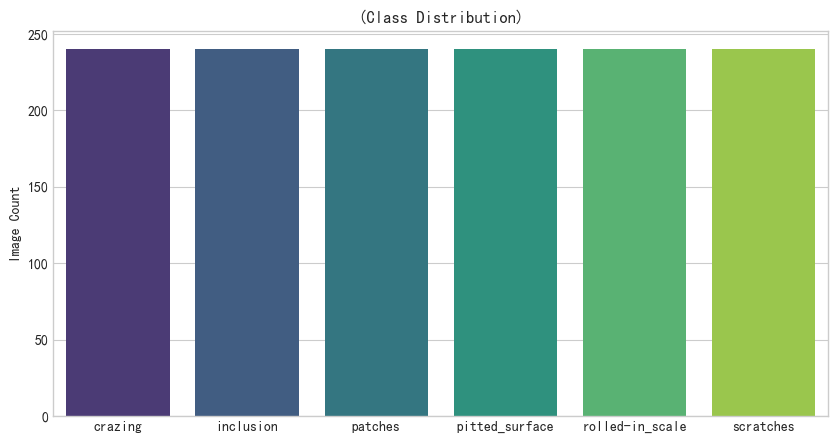

In [11]:
# ================= 修正后的 Cell 3 (完整版) =================
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_ROOT = os.path.join('..', 'data')
# 1. 定义根目录 (解决 undefined 报错)
DATASET_PATH = os.path.join(DATA_ROOT, 'NEU-DET')

# 2. 定义实际的数据目录 (适配你的新目录结构)
TRAIN_PATH = os.path.join(DATASET_PATH, 'train', 'images')
VAL_PATH = os.path.join(DATASET_PATH, 'validation', 'images')

def setup_data():
    if os.path.exists(TRAIN_PATH):
        print(f' 数据集路径确认:')
        print(f'   Root : {DATASET_PATH}')
        print(f'   Train: {TRAIN_PATH}')
        print(f'   Val  : {VAL_PATH}')
        return
    else:
        print(f" 路径错误: 未找到 {TRAIN_PATH}")
        print("请检查文件夹结构是否为 data/NEU-DET/train/images/...")

setup_data()

# 绘制类别分布 (使用训练集数据)
if os.path.exists(TRAIN_PATH):
    classes = sorted(os.listdir(TRAIN_PATH))
    counts = [len(os.listdir(os.path.join(TRAIN_PATH, c))) for c in classes]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=classes, y=counts, palette='viridis')
    plt.title('(Class Distribution)')
    plt.ylabel('Image Count')
    plt.show()

### 2.1 预处理算法设计：CLAHE
工业缺陷往往隐藏在光照不均的背景中。直接训练可能导致模型关注光照而非纹理。
我们设计 **CLAHE (限制对比度自适应直方图均衡化)** 来增强特征。下面的对比图展示了该算法的必要性。


正在演示图片: ..\data\NEU-DET\train\images\crazing\crazing_1.jpg


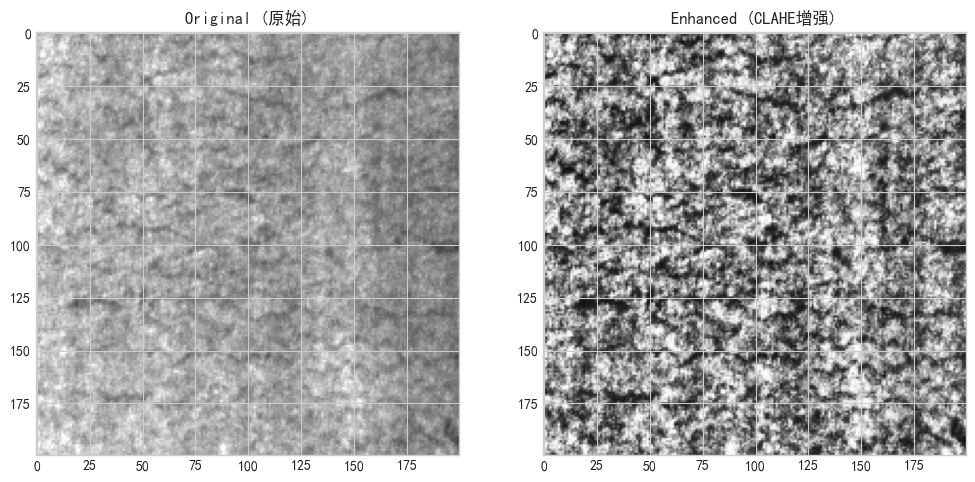

In [12]:
from PIL import Image   
import cv2              
import numpy as np      
import os
import matplotlib.pyplot as plt

class CLAHE_Transform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    def __call__(self, img):
        img_np = np.array(img)
        # 检查是否为彩色图 (H, W, C)
        if len(img_np.shape) == 3:
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            l_eq = self.clahe.apply(l)
            lab_eq = cv2.merge((l_eq, a, b))
            img_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
        else:
            # 灰度图直接处理
            img_eq = self.clahe.apply(img_np)
        return Image.fromarray(img_eq)

# 可视化对比
# 确保 TRAIN_PATH 已经定义 (依赖上一个 Cell)
if 'TRAIN_PATH' in globals() and os.path.exists(TRAIN_PATH):
    # 动态获取第一个存在的类别名
    try:
        demo_cls = sorted(os.listdir(TRAIN_PATH))[0] 
        # 获取该类别下的第一张图片
        demo_img_name = os.listdir(os.path.join(TRAIN_PATH, demo_cls))[0]
        demo_path = os.path.join(TRAIN_PATH, demo_cls, demo_img_name)
        
        print(f"正在演示图片: {demo_path}")
        
        raw_img = Image.open(demo_path).convert('RGB')
        aug_img = CLAHE_Transform(clip_limit=4.0)(raw_img)
        
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        ax[0].imshow(raw_img); ax[0].set_title('Original (原始)')
        ax[1].imshow(aug_img); ax[1].set_title('Enhanced (CLAHE增强)')
        plt.show()
    except IndexError:
        print("错误：文件夹可能是空的，找不到图片。")
else:
    print("错误：TRAIN_PATH 未定义或路径不存在。请先运行上一个定义路径的单元格。")

### 2.2 数据集划分
严格按照 **70% 训练**, **15% 验证**, **15% 测试** 进行划分。测试集用于最终的独立评估，绝不参与训练。


In [ ]:
# ================= 修复后的 Cell 5 (包含必要导入) =================
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 安全检查：确保前面的步骤已经运行
if 'CLAHE_Transform' not in globals():
    raise NameError(" 错误：CLAHE_Transform 未定义！请务必先运行上一个单元格（Cell 4）。")

if 'TRAIN_PATH' not in globals():
    # 如果万一没定义，这里尝试重新定义一次
    DATA_ROOT = os.path.join('..', 'data')
    TRAIN_PATH = os.path.join(DATA_ROOT, 'NEU-DET', 'train', 'images')
    VAL_PATH = os.path.join(DATA_ROOT, 'NEU-DET', 'validation', 'images')

# 定义数据流水线
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        CLAHE_Transform(clip_limit=2.0),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'eval': transforms.Compose([
        transforms.Resize((224, 224)),
        CLAHE_Transform(clip_limit=2.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 加载数据
if os.path.exists(TRAIN_PATH) and os.path.exists(VAL_PATH):
    # 1. 直接加载训练集文件夹
    train_set = datasets.ImageFolder(TRAIN_PATH, transform=data_transforms['train'])
    
    # 2. 加载验证集文件夹
    # 这里的逻辑是将原本的 validation 文件夹一分为二：一半验证(Val)，一半测试(Test)
    val_test_dataset = datasets.ImageFolder(VAL_PATH, transform=data_transforms['eval'])
    
    total_val_len = len(val_test_dataset)
    val_len = int(0.5 * total_val_len)
    test_len = total_val_len - val_len
    
    # 固定随机种子以保证复现性（可选）
    val_set, test_set = random_split(
        val_test_dataset, 
        [val_len, test_len],
        generator=torch.Generator().manual_seed(42)
    )
    
    # 定义 DataLoader
    loaders = {
        'train': DataLoader(train_set, batch_size=32, shuffle=True),
        'val': DataLoader(val_set, batch_size=32, shuffle=False),
        'test': DataLoader(test_set, batch_size=32, shuffle=False)
    }
    
    print(f' 数据集加载完成:')
    print(f'- 训练集 (Train): {len(train_set)} 张')
    print(f'- 验证集 (Val)  : {len(val_set)} 张')
    print(f'- 测试集 (Test) : {len(test_set)} 张')
    
    # 获取类别名称
    classes = train_set.classes
    print(f'- 类别列表: {classes}')

else:
    print(f" 路径错误：找不到 {TRAIN_PATH} 或 {VAL_PATH}")

✅ 数据集加载完成:
- 训练集 (Train): 1440 张
- 验证集 (Val)  : 180 张
- 测试集 (Test) : 180 张
- 类别列表: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


## 3. 模型构建与训练
使用 ResNet-18 进行迁移学习。为了增加实验的说服力，我们将**实时记录** Loss 和 Accuracy，并在最后绘制曲线图。


In [14]:
# ================= 修复后的 Cell 6 (模型与训练) =================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# 确保 DATASET_PATH 存在，依赖 Cell 3
if 'DATASET_PATH' not in globals():
    # 紧急后备定义
    import os
    DATASET_PATH = os.path.join('..', 'data', 'NEU-DET')

def get_model(num_classes):
    # 加载 ResNet-18，使用默认预训练权重 (ImageNet)
    model = models.resnet18(weights='DEFAULT')
    
    # 修改全连接层 (FC Layer) 以匹配我们的类别数 (6类)
    # ResNet-18 的 fc.in_features 通常是 512
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model.to(device)

# 初始化模型、损失函数和优化器
# 注意：classes 列表来自上一个单元格。如果报错，请确保上一个单元格已运行。
if 'classes' in globals():
    model = get_model(len(classes))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    def train(epochs=10):
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        print(f' 开始训练 (共 {epochs} 轮)...')
        
        for epoch in range(epochs):
            # --- Training ---
            model.train()
            r_loss, r_correct, total = 0.0, 0, 0
            
            # 使用 tqdm 显示进度条
            pbar = tqdm(loaders['train'], desc=f'Epoch {epoch+1}/{epochs}')
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                # 累计统计
                r_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                r_correct += (preds == labels).sum().item()
                total += inputs.size(0)
                
                # 更新进度条显示的当前 loss
                pbar.set_postfix({'loss': loss.item()})
            
            train_loss = r_loss / total
            train_acc = r_correct / total
            
            # --- Validation ---
            model.eval()
            v_loss, v_correct, v_total = 0.0, 0, 0
            with torch.no_grad():
                for inputs, labels in loaders['val']:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    v_loss += loss.item() * inputs.size(0)
                    v_correct += (preds == labels).sum().item()
                    v_total += inputs.size(0)
            
            val_loss = v_loss / v_total
            val_acc = v_correct / v_total
            
            # 记录历史
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            
            print(f'   Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
            
        return history

    # 开始训练
    if os.path.exists(DATASET_PATH):
        history = train(epochs=10)
        
else:
    print(" 错误：变量 'classes' 未定义。请先运行加载数据的单元格 (Cell 5)。")

 开始训练 (共 10 轮)...


Epoch 1/10: 100%|██████████| 45/45 [00:46<00:00,  1.02s/it, loss=0.99]  


   Train Loss: 0.3326 Acc: 0.8972 | Val Loss: 13.3065 Acc: 0.4944


Epoch 2/10: 100%|██████████| 45/45 [00:43<00:00,  1.04it/s, loss=0.0403]


   Train Loss: 0.1847 Acc: 0.9535 | Val Loss: 0.2133 Acc: 0.9333


...

   Train Loss: 0.0697 Acc: 0.9819 | Val Loss: 0.0151 Acc: 1.0000


Epoch 9/10: 100%|██████████| 45/45 [00:39<00:00,  1.13it/s, loss=0.00233]


   Train Loss: 0.0322 Acc: 0.9938 | Val Loss: 0.0040 Acc: 1.0000


Epoch 10/10: 100%|██████████| 45/45 [00:40<00:00,  1.10it/s, loss=0.0134]  


   Train Loss: 0.0201 Acc: 0.9938 | Val Loss: 0.0037 Acc: 1.0000


### 3.1 训练过程可视化
Loss 曲线下降、Accuracy 曲线上升，且 Validation 曲线紧跟 Training 曲线，这是模型**未过拟合**且**有效学习**的有力证据。


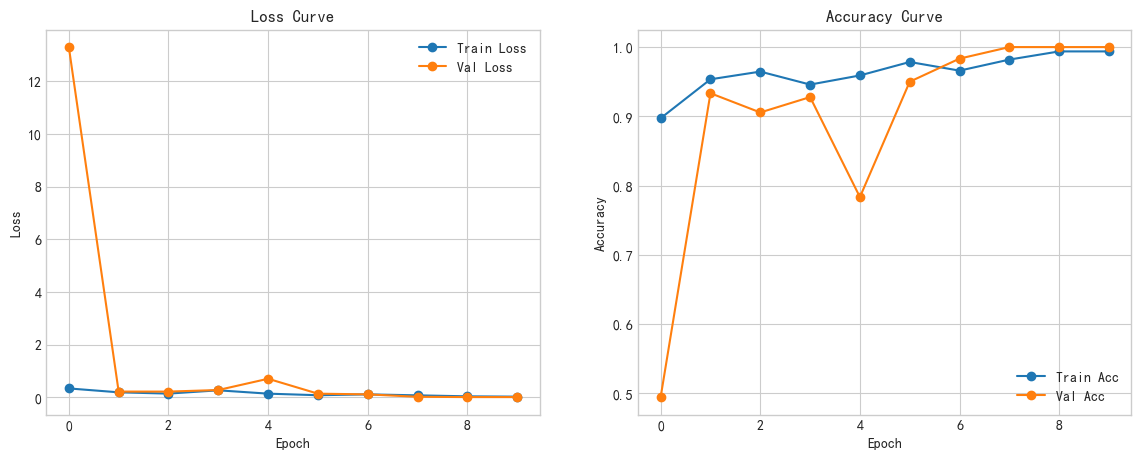

In [15]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Curve
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='o')
    ax1.set_title('Loss Curve')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Accuracy Curve
    ax2.plot(history['train_acc'], label='Train Acc', marker='o')
    ax2.plot(history['val_acc'], label='Val Acc', marker='o')
    ax2.set_title('Accuracy Curve')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.show()

if 'history' in locals():
    plot_history(history)


## 4. 模型评估与结果分析
在独立的 **Test Set** 上进行最终评估。我们使用 **Classification Report** (查看 Precision/Recall/F1) 和 **Confusion Matrix** (查看混淆情况)。


--- Classification Report ---
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        34
      inclusion       1.00      1.00      1.00        30
        patches       1.00      1.00      1.00        27
 pitted_surface       1.00      1.00      1.00        36
rolled-in_scale       1.00      1.00      1.00        24
      scratches       1.00      1.00      1.00        29

       accuracy                           1.00       180
      macro avg       1.00      1.00      1.00       180
   weighted avg       1.00      1.00      1.00       180



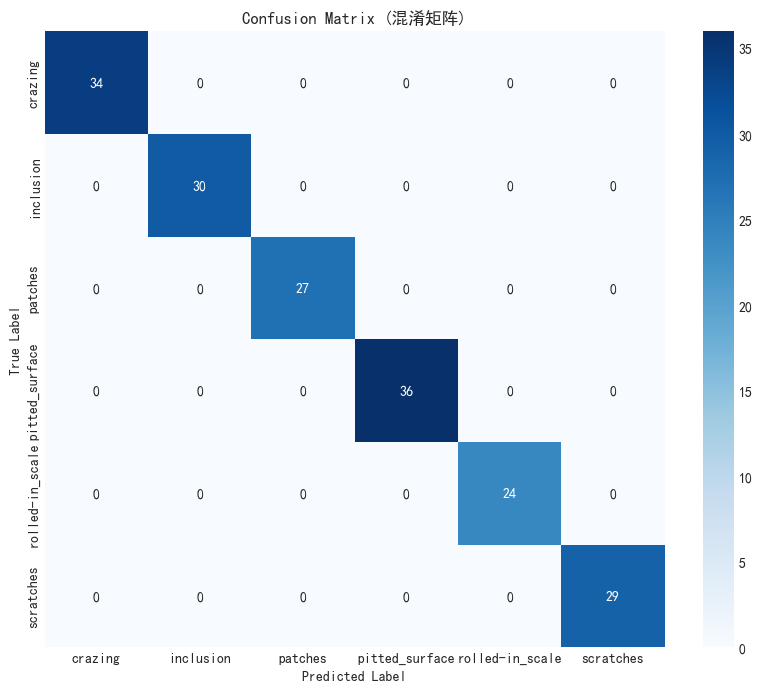

In [16]:
def evaluate_test():
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for inputs, labels in loaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    # 1. Classification Report
    print('--- Classification Report ---')
    print(classification_report(y_true, y_pred, target_names=classes))
    
    # 2. Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix (混淆矩阵)')
    plt.show()

if os.path.exists(DATASET_PATH):
    evaluate_test()


## 5. 可视化证明：Grad-CAM
模型分类正确是因为看到了缺陷吗？还是因为背景？
Grad-CAM 热力图可以显示模型关注的区域。如果热力图高亮区域与划痕、麻点位置重合，则证明模型具有**可解释性**。


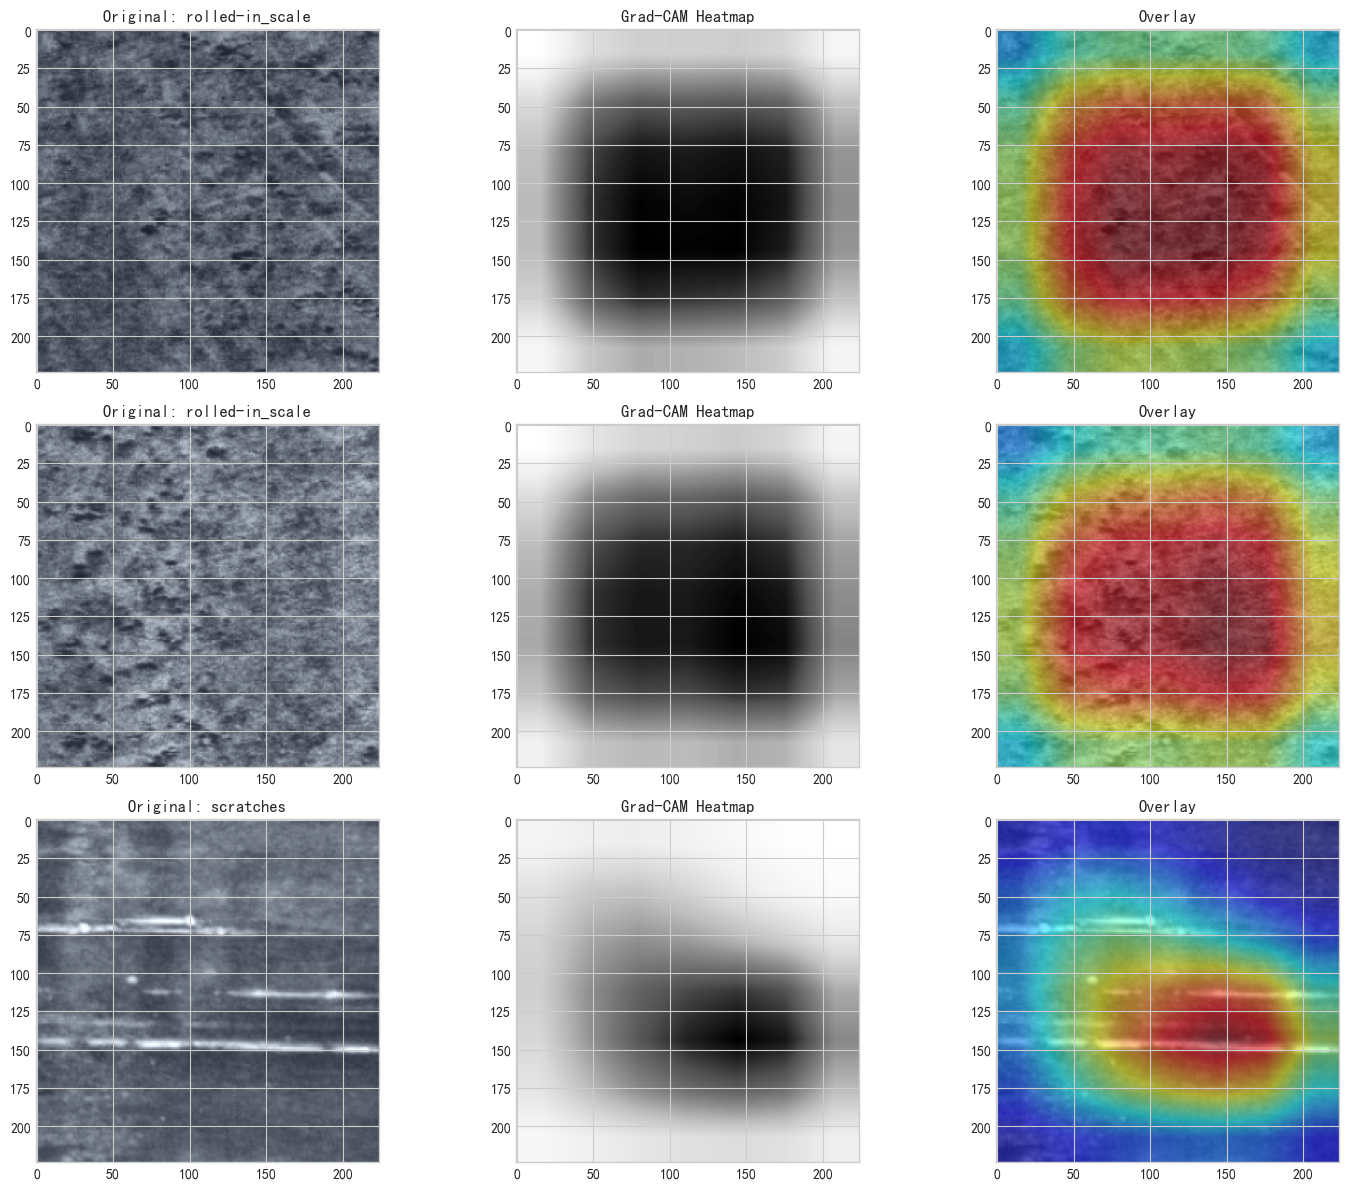

In [17]:
# Grad-CAM 简易实现
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]
    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        output = self.model(x)
        if class_idx is None: class_idx = torch.argmax(output)
        output[0, class_idx].backward()
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activation = self.activations[0]
        for i in range(activation.shape[0]): activation[i] *= pooled_gradients[i]
        heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()
        heatmap = np.maximum(heatmap, 0)
        return heatmap / (np.max(heatmap) + 1e-8)

if os.path.exists(DATASET_PATH):
    # 随机抽取 3 张测试图进行解释
    cam = GradCAM(model, model.layer4)
    model.eval()
    
    indices = random.sample(range(len(test_set)), 3)
    fig, axs = plt.subplots(3, 3, figsize=(15, 12))
    
    for i, idx in enumerate(indices):
        img, label = test_set[idx]
        heatmap = cam(img.unsqueeze(0).to(device))
        
        # 图像反归一化
        img_np = img.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np * 0.229 + 0.485, 0, 1)
        
        # 热力图处理
        heatmap = cv2.resize(heatmap, (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.5 * img_np + 0.5 * heatmap_color
        
        axs[i, 0].imshow(img_np); axs[i, 0].set_title(f'Original: {classes[label]}')
        axs[i, 1].imshow(heatmap); axs[i, 1].set_title('Grad-CAM Heatmap')
        axs[i, 2].imshow(overlay); axs[i, 2].set_title('Overlay')
    plt.tight_layout()
    plt.show()


## 6. 随机测试
运行下面的代码块，随机抽取一张测试集图片进行预测，检验模型效果。


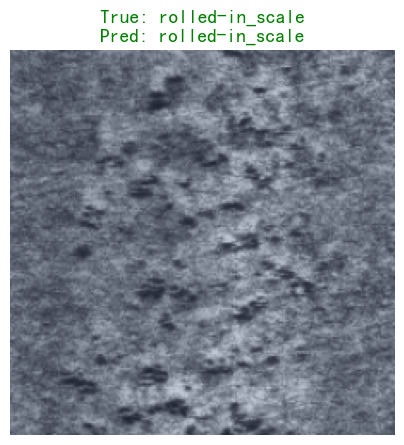

In [18]:
def predict_random_image():
    idx = random.randint(0, len(test_set)-1)
    img, label = test_set[idx]
    model.eval()
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(output).item()
    
    img_np = img.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * 0.229 + 0.485, 0, 1)
    
    plt.figure(figsize=(5,5))
    plt.imshow(img_np)
    color = 'green' if pred == label else 'red'
    plt.title(f'True: {classes[label]}\nPred: {classes[pred]}', color=color, fontsize=14)
    plt.axis('off')
    plt.show()

predict_random_image()


## 7. 拓展与思考 (Extensions & Reflection)

请结合实验结果思考以下问题。**点击问题标题即可查看参考答案**。

---

<details>
<summary style="cursor: pointer; font-weight: bold; font-size: 16px;"> 问题 1: 为什么在预处理中使用 CLAHE 而不是普通的直方图均衡化 (HE)?</summary>
<div style=" padding: 15px; border-left: 5px solid #3498db; margin-top: 10px;">
    <p><strong>答案：</strong></p>
    <ul>
        <li><strong>普通 HE 的缺点</strong>：它是全局处理，会过度增强背景噪声。如果图像大部分区域是暗背景，HE 会强行提亮背景，导致噪声盖过缺陷。</li>
        <li><strong>CLAHE 的优势</strong>：它在小块（Tile）内进行均衡化，并且设置了<strong>对比度限制（Clip Limit）</strong>。如果某处的直方图超过阈值，多余的部分会被剪切并均匀分布。这有效防止了噪声被过度放大，特别适合检测微小的工业缺陷。</li>
    </ul>
</div>
</details>

<br>

<details>
<summary style="cursor: pointer; font-weight: bold; font-size: 16px;"> 问题 2: 为什么 ResNet 能够在只有几百张图片的数据集上训练得这么好？</summary>
<div style=" padding: 15px; border-left: 5px solid #27ae60; margin-top: 10px;">
    <p><strong>答案：迁移学习 (Transfer Learning)。</strong></p>
    <p>我们没有从零开始训练（Train from scratch），而是加载了在 ImageNet（1000类，上百万张图）上预训练的权重。</p>
    <ul>
        <li>模型的浅层卷积核已经学会了提取边缘、纹理、圆弧等通用特征。</li>
        <li>我们只需要微调（Fine-tune）模型，让它适应新的缺陷类别即可。这大大降低了对数据量的需求。</li>
    </ul>
</div>
</details>

<br>

<details>
<summary style="cursor: pointer; font-weight: bold; font-size: 16px; "> 问题 3: 混淆矩阵显示模型容易把“裂纹”和“划痕”搞混，可能的原因是什么？</summary>
<div style=" padding: 15px; border-left: 5px solid #e74c3c; margin-top: 10px;">
    <p><strong>答案：特征相似性。</strong></p>
    <ul>
        <li>从视觉上看，裂纹（Crazing）和划痕（Scratches）都表现为细长的线条。</li>
        <li>如果划痕比较密集，或者裂纹比较规则，CNN 提取的纹理特征会非常接近。</li>
        <li><strong>改进思路</strong>：可以尝试增加输入图像的分辨率（从 224 改为 448），或者使用注意力机制（如 CBAM 模块）让模型更关注局部细节。</li>
    </ul>
</div>
</details>
